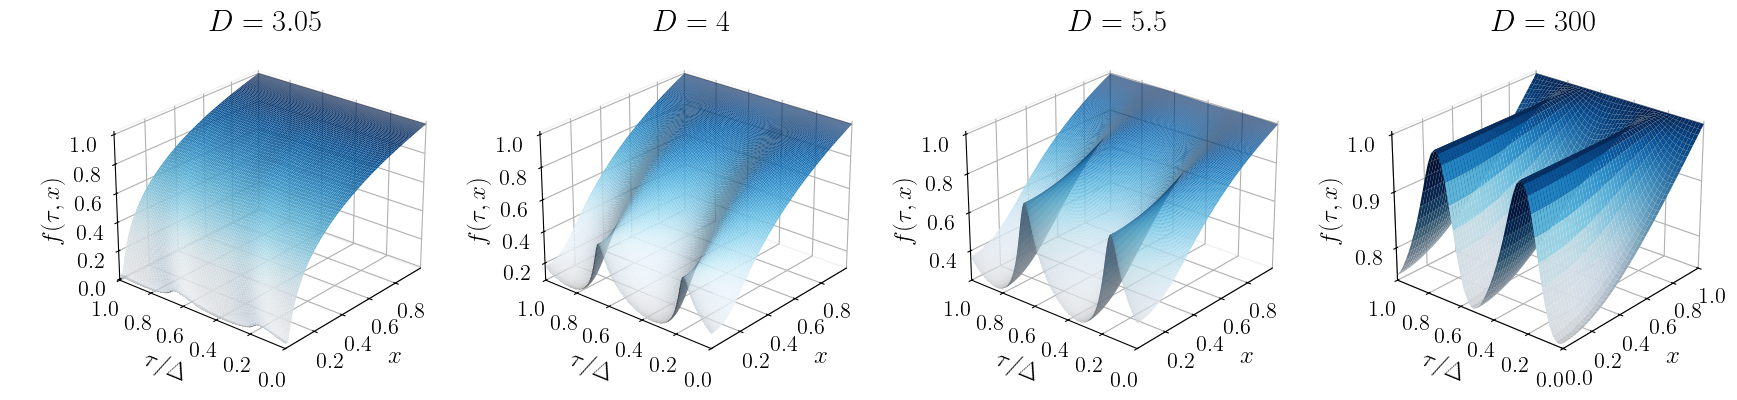

In [ ]:
import json
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

# LaTeX font
plt.rcParams.update({
    "text.usetex": True,
    'font.size': 18
    })


# --------------------------------------------------
# Helper: load flat list JSON: [t, x, f, PI, PSI, Omega]
# --------------------------------------------------
def load_fields_highD(fname):
    with open(fname, "r") as f:
        arr = np.array(json.load(f), dtype=float)

    t, x = arr[:, 0], arr[:, 1]
    f_field, pi, psi, omega = arr[:, 2], arr[:, 3], arr[:, 4], arr[:, 5]

    t_vals = np.unique(t)
    x_vals = np.unique(x)
    nt, nx = len(t_vals), len(x_vals)

    order = np.lexsort((x, t))
    f_field = f_field[order].reshape(nt, nx)
    pi      = pi[order].reshape(nt, nx)
    psi     = psi[order].reshape(nt, nx)
    omega   = omega[order].reshape(nt, nx)

    X, T = np.meshgrid(x_vals, t_vals)
    delta = t_vals[-1] - t_vals[0] if nt > 1 else 1.0

    return X, T, delta, f_field, omega, pi, psi

def load_dataset(fname):
    with open(fname, "r") as f:
        data = json.load(f)

    # identify x-keys (strings) and x-values (floats)
    x_keys = sorted([k for k in data.keys() if k != "Delta"], key=float)
    x_vals = np.array([float(k) for k in x_keys])

    data["x"] = x_vals

    # tau-values: use the first x-key directly (string)
    n_tau = len(data[x_keys[0]]["A"])
    data["tau"] = np.linspace(0, data["Delta"], num=n_tau)

    # assemble field data
    fs = []
    for x_key in x_keys:
        fs.append(data[x_key]["f"])

    data["f"] = np.array(fs).T

    # mesh
    x, t = np.meshgrid(data["x"], data["tau"])
    delta = data["Delta"]

    f = data["f"]

    return x, t, delta, f

# --------------------------------------------------
# Load dataset
# --------------------------------------------------
X_0, T_0, delta_0, f_0 = load_dataset("fields_3.046000_0.json")
X_1, T_1, delta_1, f_1 = load_dataset("fields_4.000000_0.json")
X_2, T_2, delta_2, f_2 = load_dataset("fields_5.500000_0.json")
X_3, T_3, delta_3, f_3, dummy, dummy, dummy = load_fields_highD("../largeD_data/example.json")

fields = [
    (f_0, r"$f(\tau,x)$",     mpl.cm.Blues),
    (f_1, r"$f(\tau,x)$",mpl.cm.Blues),
    (f_2, r"$f(\tau,x)$",   mpl.cm.Blues),
    (f_3, r"$f(\tau,x)$",  mpl.cm.Blues),
]

deltas = [delta_0, delta_1, delta_2, delta_3]
   
Xs = [X_0, X_1, X_2, X_3]
Ts = [T_0, T_1, T_2, T_3]

column_titles = [
    r"$D=3.05$",
    r"$D=4$",
    r"$D=5.5$",
    r"$D=300$"
]

# --------------------------------------------------
# 1×(4+1) layout with empty spacer column
# --------------------------------------------------
fig, axes = plt.subplots(
    nrows=1,
    ncols=5,                      # <-- extra column
    figsize=(18, 4.2),
    subplot_kw={"projection": "3d"},
    gridspec_kw={"width_ratios": [0.12, 1.2, 1.2, 1.2, 1.2]},
)

ls = LightSource(azdeg=315, altdeg=45)

# plot into columns 1..4
for i, (field, zlabel, cmap) in enumerate(fields):
    ax = axes[i + 1]

    rgb = ls.shade(field, cmap=cmap, vert_exag=0.1, blend_mode="soft")
    ax.plot_surface(
        Xs[i],
        Ts[i] / deltas[i],
        field,
        facecolors=rgb,
        rstride=1,
        cstride=1,
        linewidth=0,
        antialiased=True,
        rasterized=True,
    )

    ax.set_xlim(np.min(Xs[i]), np.max(Xs[i]))
    ax.set_ylim(0, 1)

    ax.set_xlabel(r"$x$", fontsize=18, labelpad=8)
    ax.set_ylabel(r"$\tau/\Delta$", fontsize=18, labelpad=8)

    ax.zaxis.set_rotate_label(False)
    ax.set_zlabel(zlabel, fontsize=18, rotation=90, labelpad=5)

    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=16)
    ax.tick_params(axis="z", labelsize=16)

    ax.view_init(elev=25, azim=-140)

    ax.set_title(column_titles[i], fontsize=22, pad=5)

    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

# --------------------------------------------------
# Hide spacer column
# --------------------------------------------------
axes[0].axis("off")

plt.subplots_adjust(left=0.03, right=0.98, wspace=0.15)
plt.tight_layout()

plt.savefig("f_comparison.pdf", dpi=100, bbox_inches="tight")
plt.show()
